# Trabajo Final AMq1


Participantes:

*   a2412 | Martín Gabriel Quiroga
*   a2407 | Mariano Jauffroy
*   a2406 | Andrés Pablo García



## Imports

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os
import optuna
import xgboost as xgb

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. EDA

### 2.2. Análisis Inicial

In [25]:
route = "dataset/star_classification.csv"
df = pd.read_csv(route)

## 3. Preparación del dataset

### 3.1. Tratamiento outliers y eliminación de clases minoritarias

In [26]:
# se elimina el outlier detectado en la etapa anterior

anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]
df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

In [27]:
# ============================================================
# Generación del DataFrame 1: Clase mayoritaria por obj_ID
# ============================================================

# 1. Identificar grupos con más de un registro por obj_ID
group_counts = df.groupby('obj_ID').size()
duplicated_obj_ids = group_counts[group_counts > 1].index
unique_obj_ids = group_counts[group_counts == 1].index

print(f"Total de obj_IDs únicos: {df['obj_ID'].nunique()}")
print(f"obj_IDs con un solo registro: {len(unique_obj_ids)}")
print(f"obj_IDs con múltiples registros: {len(duplicated_obj_ids)}")
print(f"Total de registros en el dataset original: {len(df)}")
print("=" * 70)

# 2. Analizar la situación de cada grupo con múltiples registros
rows_to_keep = []
total_discarded = 0

for obj_id in duplicated_obj_ids:
    group = df[df['obj_ID'] == obj_id]
    class_counts = group['class'].value_counts()

    # Verificar si hay más de una clase en el grupo
    has_conflict = len(class_counts) > 1
    majority_class = class_counts.idxmax()
    majority_count = class_counts.max()
    total_in_group = len(group)

    if has_conflict:
        minority_count = total_in_group - majority_count
        total_discarded += minority_count
        # print(f"\n🔀 obj_ID: {obj_id}")
        # print(f"   Total registros: {total_in_group}")
        # print(f"   Distribución de clases: {dict(class_counts)}")
        # print(f"   Clase mayoritaria: '{majority_class}' ({majority_count} registros)")
        # print(f"   Registros descartados (clases minoritarias): {minority_count}")

    # Conservar solo los registros de la clase mayoritaria
    rows_to_keep.append(group[group['class'] == majority_class])

# 3. Agregar los registros de obj_IDs únicos (sin duplicados)
unique_rows = df[df['obj_ID'].isin(unique_obj_ids)]

# 4. Construir el DataFrame filtrado
df_majority = pd.concat([unique_rows] + rows_to_keep, ignore_index=True)

print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
print(f"Registros originales: {len(df)}")
print(f"Registros descartados por clase minoritaria: {total_discarded}")
print(f"Registros en df_majority: {len(df_majority)}")
print(f"\nDistribución de clases en df original:")
print(df['class'].value_counts())
print(f"\nDistribución de clases en df_majority:")
print(df_majority['class'].value_counts())

Total de obj_IDs únicos: 78052
obj_IDs con un solo registro: 62693
obj_IDs con múltiples registros: 15359
Total de registros en el dataset original: 99999

RESUMEN FINAL
Registros originales: 99999
Registros descartados por clase minoritaria: 6340
Registros en df_majority: 93659

Distribución de clases en df original:
class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

Distribución de clases en df_majority:
class
GALAXY    57928
STAR      19345
QSO       16386
Name: count, dtype: int64


### 3.2. Split del dataset

In [28]:
# se reliza el split tomando en cuenta de no "dividir"
# los diferentes registros de un mismo obj_ID para evitar data leakage
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(df_majority, groups=df_majority['obj_ID']))

train_df = df_majority.iloc[train_idx]
test_df = df_majority.iloc[test_idx]

y_train = train_df['class']
y_test = test_df['class']

### 3.3. Selección de Features

In [30]:
# se seleccionan las variables físicas y fotométricas mencionadas en EDA

features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df['class']
y_test = test_df['class']

### 3.4. Encoding de Target (categórica) y Escalado de Features

In [31]:
# Encoding de variable categórica
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [32]:
# Escalado de variables
# (necesario para modelos KNN y SVM)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.5. Utils

In [33]:
def show_metrics(y_true, y_pred, cm_classes = None, cm_title = "Matriz de confusión"):
  # Se imprimen las métricas
  cm = confusion_matrix(y_true, y_pred)

  disp_cm = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=cm_classes
  )

  fig, ax = plt.subplots(figsize=(6, 6))
  ax.grid = False
  disp_cm.plot(ax=ax)
  ax.set_title(cm_title)

  # Accuracy
  acc = accuracy_score(y_true, y_pred)

  # F1-score
  f1_macro = f1_score(y_true, y_pred, average='macro')
  f1_weighted = f1_score(y_true, y_pred, average='weighted')

  # Precision y Recall
  precision_macro = precision_score(y_true, y_pred, average='macro')
  recall_macro = recall_score(y_true, y_pred, average='macro')

  print("Accuracy:", acc)
  print("F1 (macro):", f1_macro)
  print("F1 (weighted):", f1_weighted)
  print("Precision (macro):", precision_macro)
  print("Recall (macro):", recall_macro)

## 8. Random Forest

### 8.2 Random Forest de features físicas

--- Importancia de Variables (RF - Solo Físicas) ---
redshift    0.612458
z           0.081251
i           0.077135
g           0.075700
u           0.071308
r           0.050975
alpha       0.015793
delta       0.015380
dtype: float64


Accuracy: 0.9806189099475319
F1 (macro): 0.9764977385755467
F1 (weighted): 0.980516033286027
Precision (macro): 0.9793011785326037
Recall (macro): 0.9738526095596619


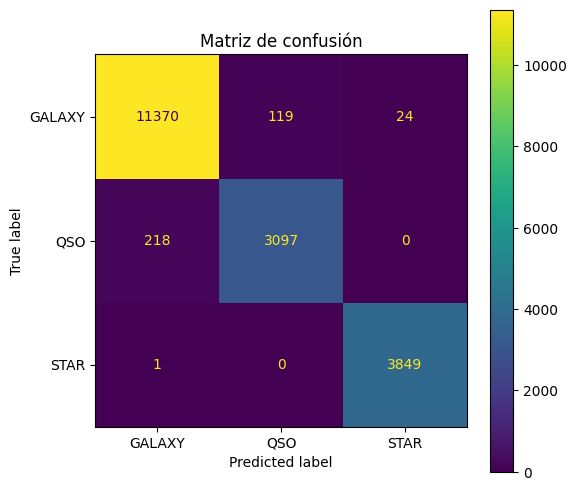

In [34]:
# 1. Definición de variables físicas
features_fisicas = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

# 2. Recorte de los conjuntos de entrenamiento y prueba
X_train_rf_fisicas = train_df[features_fisicas]
X_test_rf_fisicas = test_df[features_fisicas]

# 3. Creación y entrenamiento del modelo Random Forest
rf_fisicas = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fisicas.fit(X_train_rf_fisicas, y_train)

# 4. Generación de predicciones
y_pred_rf_fisicas = rf_fisicas.predict(X_test_rf_fisicas)

# 5. Análisis de importancia de variables
importances_fisicas = pd.Series(rf_fisicas.feature_importances_, index=features_fisicas).sort_values(ascending=False)
print("--- Importancia de Variables (RF - Solo Físicas) ---")
print(importances_fisicas)
print("\n" + "="*40 + "\n")

# 6. Evaluación de métricas
show_metrics(y_test, y_pred_rf_fisicas, cm_classes=le.classes_)

## 9. Boosting con XGBoost

In [35]:
n_samples = 10000
X_train_sub, y_train_sub = resample(
    X_train_scaled,
    y_train,
    n_samples=n_samples,
    replace=False,
    random_state=42,
    stratify=y_train
)

def objective(trial):
    params = {
        # Ensamble y aprendizaje
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),

        # Complejidad del árbol
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Subsampling
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),

        # Regularización
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),

        # Fijos
        'objective': 'multi:softmax',
        'num_class': 3,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
    }

    clf = xgb.XGBClassifier(**params)

    scores = cross_val_score(
        clf, X_train_sub, y_train_sub,
        cv=5, scoring='accuracy', n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25, show_progress_bar=True, timeout=3600)

print("Mejores hiperparámetros encontrados:", study.best_params)
print("Mejor puntuación de validación cruzada:", study.best_value)

[I 2026-05-25 19:55:37,004] A new study created in memory with name: no-name-a9ab732f-54dd-45f8-bfd1-0d08dc6abeaf
Best trial: 0. Best value: 0.9719:   4%|▍         | 1/25 [00:05<02:05,  5.24s/it, 5.24/3600 seconds]

[I 2026-05-25 19:55:42,244] Trial 0 finished with value: 0.9719000000000001 and parameters: {'n_estimators': 488, 'learning_rate': 0.034515604609284836, 'max_depth': 10, 'min_child_weight': 6, 'gamma': 3.7749742677339593, 'subsample': 0.6038383621791104, 'colsample_bytree': 0.99070897984767, 'reg_alpha': 0.0032467759470830144, 'reg_lambda': 0.0006431365290921752}. Best is trial 0 with value: 0.9719000000000001.


Best trial: 1. Best value: 0.9735:   8%|▊         | 2/25 [00:08<01:33,  4.05s/it, 8.46/3600 seconds]

[I 2026-05-25 19:55:45,464] Trial 1 finished with value: 0.9734999999999999 and parameters: {'n_estimators': 139, 'learning_rate': 0.05916591153578304, 'max_depth': 6, 'min_child_weight': 4, 'gamma': 1.8659321047055843, 'subsample': 0.9202189106851941, 'colsample_bytree': 0.565495436975633, 'reg_alpha': 0.1395965604767913, 'reg_lambda': 0.25897982819396786}. Best is trial 1 with value: 0.9734999999999999.


Best trial: 1. Best value: 0.9735:  12%|█▏        | 3/25 [00:12<01:27,  3.96s/it, 12.32/3600 seconds]

...

[I 2026-05-25 19:56:49,436] Trial 22 finished with value: 0.9749000000000001 and parameters: {'n_estimators': 895, 'learning_rate': 0.01490644211401666, 'max_depth': 9, 'min_child_weight': 8, 'gamma': 0.794468985545181, 'subsample': 0.6977099708254416, 'colsample_bytree': 0.5913419189273638, 'reg_alpha': 0.04288060866126268, 'reg_lambda': 0.009409224280607262}. Best is trial 19 with value: 0.9752000000000001.


Best trial: 19. Best value: 0.9752:  96%|█████████▌| 24/25 [01:17<00:04,  4.58s/it, 77.04/3600 seconds]

[I 2026-05-25 19:56:54,044] Trial 23 finished with value: 0.9745000000000001 and parameters: {'n_estimators': 906, 'learning_rate': 0.010084799054655886, 'max_depth': 9, 'min_child_weight': 9, 'gamma': 1.1108896027020725, 'subsample': 0.7484686707079885, 'colsample_bytree': 0.5790003602096846, 'reg_alpha': 0.031671848900256074, 'reg_lambda': 0.05116863828129218}. Best is trial 19 with value: 0.9752000000000001.


Best trial: 19. Best value: 0.9752: 100%|██████████| 25/25 [01:20<00:00,  3.23s/it, 80.64/3600 seconds]

[I 2026-05-25 19:56:57,644] Trial 24 finished with value: 0.9726000000000001 and parameters: {'n_estimators': 873, 'learning_rate': 0.015600444270654492, 'max_depth': 10, 'min_child_weight': 7, 'gamma': 2.29640832078791, 'subsample': 0.7295186310110429, 'colsample_bytree': 0.44362651749514503, 'reg_alpha': 0.4083765663195775, 'reg_lambda': 0.006950032803907419}. Best is trial 19 with value: 0.9752000000000001.
Mejores hiperparámetros encontrados: {'n_estimators': 960, 'learning_rate': 0.013608699694871267, 'max_depth': 9, 'min_child_weight': 8, 'gamma': 0.762244427159162, 'subsample': 0.6901507385142174, 'colsample_bytree': 0.5818060586756644, 'reg_alpha': 0.02025311986116342, 'reg_lambda': 0.013971268504256788}
Mejor puntuación de validación cruzada: 0.9752000000000001


In [36]:
# Mejores hiperparámetros encontrados: {'n_estimators': 471, 'learning_rate': 0.018850609797582824, 'max_depth': 7, 'min_child_weight': 4, 'gamma': 0.5362773100776411, 'subsample': 0.7057408639743612, 'colsample_bytree': 0.6554406985045177, 'reg_alpha': 0.03857290302791919, 'reg_lambda': 1.064183042415151}
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
best_xgb.fit(X_train_scaled, y_train)

y_pred = best_xgb.predict(X_test_scaled)

Accuracy: 0.9793875147232037
F1 (macro): 0.9752167358141479
F1 (weighted): 0.9793145889845257
Precision (macro): 0.9781789070680507
Recall (macro): 0.9723607339263299


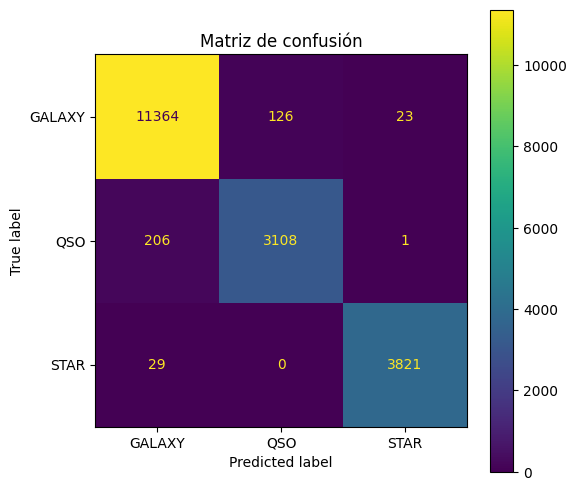

In [37]:
show_metrics(y_test, y_pred, le.classes_)

## 10. (Nuevo) Serializacion

In [ ]:
# ── SERIALIZACIÓN ──────────────────────────────────────────
os.makedirs("artifacts", exist_ok=True)

joblib.dump(rf_fisicas, "artifacts/modelo.pkl")
joblib.dump(features_fisicas, "artifacts/features.pkl")
joblib.dump(le, "artifacts/label_encoder.pkl")

print("Modelo serializado en artifacts/")

"""
Por qué guardar esas tres cosas

modelo.pkl — el Random Forest entrenado. Obvio.

features.pkl — la lista de columnas en el orden exacto en que el modelo fue entrenado. 
Cuando el endpoint reciba un registro nuevo, necesita armar el DataFrame con esas columnas en ese orden. 
Si no guardás esto, tenés que hardcodearlo en otro lado y es fácil que se desincronice.

label_encoder.pkl — tu modelo probablemente predice clases como 0, 1, 2. 
El LabelEncoder te permite convertir eso de vuelta a los nombres originales (STAR, GALAXY, QSO o lo que sean). 
El endpoint debería devolver el nombre, no el número.
"""

Modelo serializado en artifacts/


'\nPor qué guardar esas tres cosas\nmodelo.pkl — el Random Forest entrenado. Obvio.\nfeatures.pkl — la lista de columnas en el orden exacto en que el modelo fue entrenado. \nCuando el endpoint reciba un registro nuevo, necesita armar el DataFrame con esas columnas en ese orden. \nSi no guardás esto, tenés que hardcodearlo en otro lado y es fácil que se desincronice.\nlabel_encoder.pkl — tu modelo probablemente predice clases como 0, 1, 2. \nEl LabelEncoder te permite convertir eso de vuelta a los nombres originales (STAR, GALAXY, QSO o lo que sean). \nEl endpoint debería devolver el nombre, no el número.\n'

In [30]:
import mlflow
print(mlflow.__version__)

3.12.0


La carpeta del proyecto tiene que quedar algo como esto.

proyecto/
├── artifacts/
│   ├── modelo.pkl
│   ├── features.pkl
│   └── label_encoder.pkl
├── train.py          ← tu notebook convertido a .py
├── app.py            ← el endpoint (FastAPI)
└── Dockerfile